# Legacy methods, `ml_uncertainty_msc` sine, N=50

The pre-rewrite uncertainty methods on the **current `ml_uncertainty_msc`** data
recipe: `sin_homo` with `sigma = 0.1`, a regular training grid on `[0, 6]`, an
evaluation grid of 1000 points on `[-2, 8]`, seed 42 -- with the training-set
size cut to 50.

The methods are fed the **raw** arrays, which is what the legacy code did.

**Provenance.** `legacy_models.py` is a verbatim `git show 28b7615^:src/models.py`
from `ml_uncertainty_msc`. `legacy_methods.py` is *reconstructed from bytecode* --
the original `src/methods.py` was never committed and survives only as a stale
`__pycache__` entry, so its structure, constants and defaults are read off the
disassembly while local variable names and comments are guesswork.

**This is a probe, not a result.** It reproduces an older, different estimator of
predictive uncertainty (a band of +-2 sigma from a single total standard
deviation, dashed line = clean sin(x)); it is not the current `Prediction`
interface, and its numbers do not belong in the thesis tables.

In [1]:
import sys
sys.path.insert(0, ".")   # this folder only; the fidelity checks locate their
                          # reference trees themselves, by absolute path

import numpy as np
import torch
import matplotlib.pyplot as plt

from legacy_models import make_gp, train_mlp
from legacy_methods import (
    mc_dropout_predict,
    train_ensemble,
    ensemble_predict,
    laplace_ll_predict,
    train_vi,
    vi_predict,
)
from legacy_plotting import plot_uncertainty_for_1d_data

FIGDIR = "figures"

import legacy_data

SEED = 42
N_TRAIN = 50

np.random.seed(SEED)
torch.manual_seed(SEED)

# The data recipe here is a copy of ml_uncertainty_msc's src/data.py.
# Prove it has not drifted (pinned to that repo by absolute path).
print(legacy_data.check_matches_live())

OK: make_sin_homo(250) == load_sin_homo() on all 7 arrays (reference: C:\Users\michal\Desktop\ml_uncertainty_msc)


## Data

train (50, 1) on [0.0, 6.0]  (regular grid)
eval  (1000, 1) on [-2.0, 8.0]


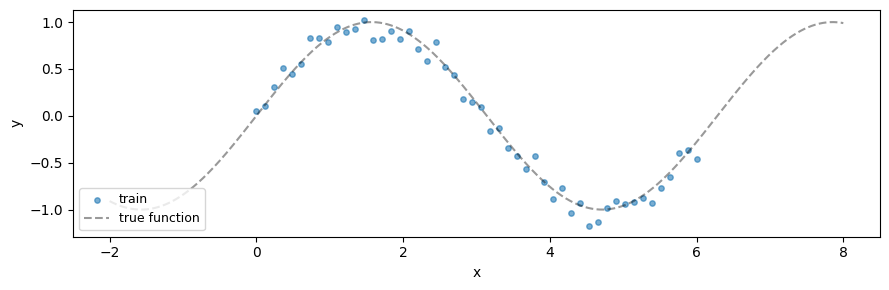

In [2]:
data = legacy_data.make_sin_homo(n_train=N_TRAIN, seed=SEED)

X_train, y_train = data.X_train, data.y_train
X_eval, y_eval = data.X_eval, data.y_eval


def show(y_pred, y_std, title, out_path):
    """No transform: the methods are fitted and plotted in the same units."""
    plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval,
                                 y_pred, y_std, title, out_path)


print(f"train {X_train.shape} on [{X_train.min():.1f}, {X_train.max():.1f}]  (regular grid)")
print(f"eval  {X_eval.shape} on [{X_eval.min():.1f}, {X_eval.max():.1f}]")

fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(X_train, y_train, s=15, alpha=0.6, label="train")
ax.plot(X_eval, y_eval, "k--", alpha=0.4, label="true function")
ax.legend(loc="lower left", fontsize=9)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Laplace approximation

Last layer, full Hessian; prior precision tuned by marginal likelihood.

noise_std_ = 0.0830


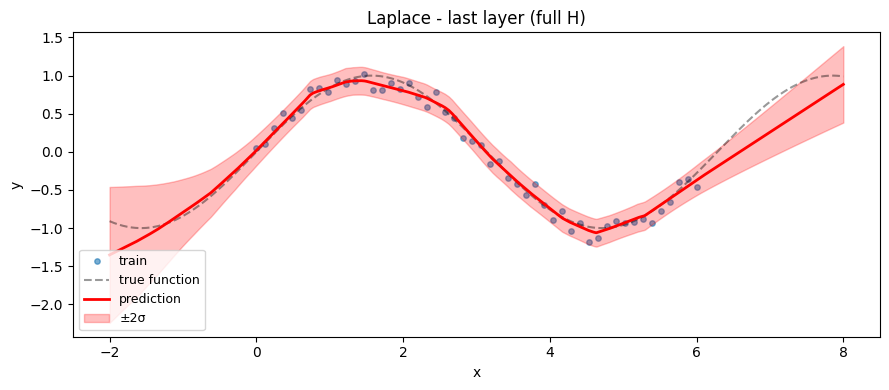

In [3]:
nn_map = train_mlp(X_train, y_train, epochs=1000, seed=SEED)
print(f"noise_std_ = {nn_map.noise_std_:.4f}")

y_pred, y_std = laplace_ll_predict(nn_map, X_train, y_train, X_eval)
show(y_pred, y_std, "Laplace - last layer (full H)", f"{FIGDIR}/n50_laplace.png")

## Gaussian process

1.29**2 * RBF(length_scale=1.73) + WhiteKernel(noise_level=0.016)


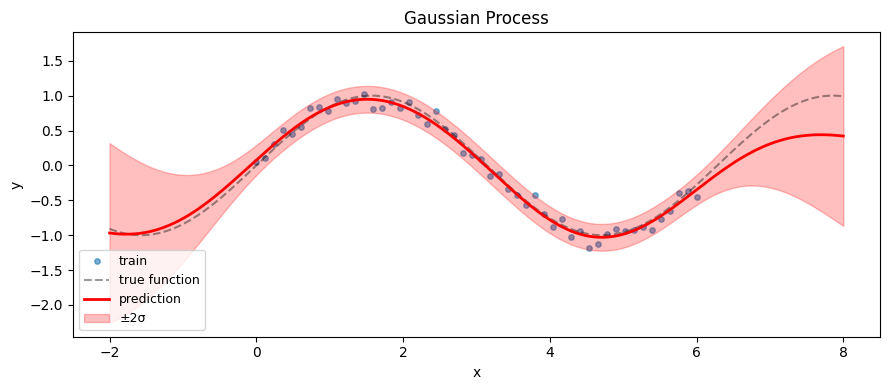

In [4]:
gp = make_gp(random_state=SEED).fit(X_train, y_train)
print(gp.kernel_)

y_pred, y_std = gp.predict(X_eval, return_std=True)
show(y_pred, y_std, "Gaussian Process", f"{FIGDIR}/n50_gp.png")

## Monte Carlo dropout

(Gal & Ghahramani 2016). The aleatoric part is the scalar residual `noise_std_` measured after training, not the network's log-variance head -- which is why the band below barely widens away from the data.

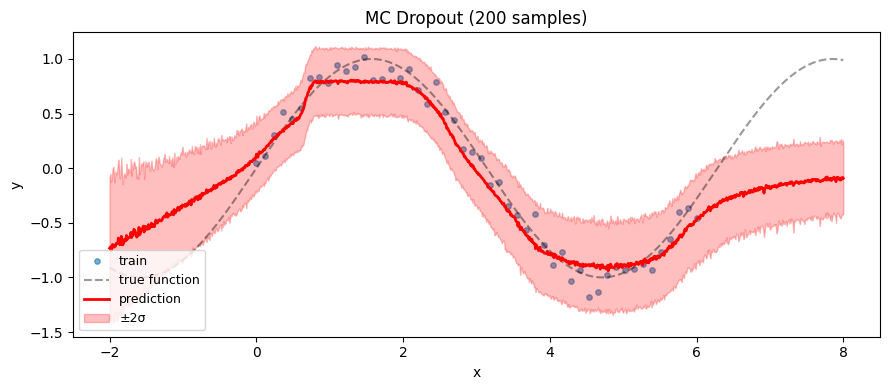

In [5]:
nn_dropout = train_mlp(X_train, y_train, dropout=0.2, epochs=1000, seed=SEED)
y_pred, y_std = mc_dropout_predict(nn_dropout, X_eval, n_samples=200)
show(y_pred, y_std, "MC Dropout (200 samples)", f"{FIGDIR}/n50_mcdropout.png")

## Deep ensemble

Ten MAP networks; member *i* is trained with `seed=i` -- that indexing is baked into the legacy `train_ensemble`, so it does not follow `SEED`.

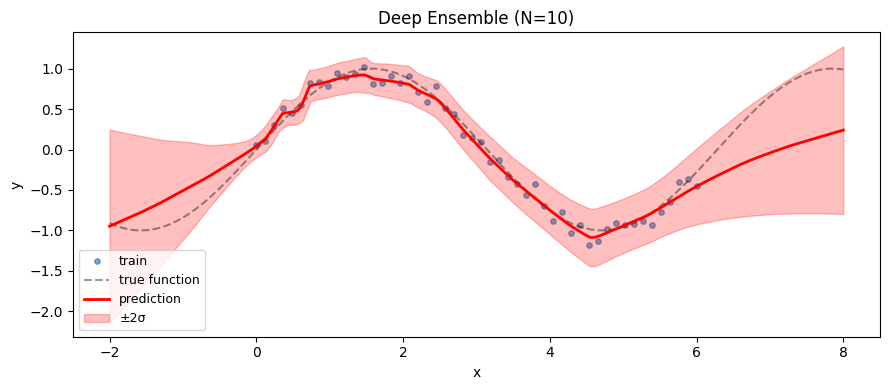

In [6]:
ensemble = train_ensemble(X_train, y_train, n_models=10, epochs=1000)
y_pred, y_std = ensemble_predict(ensemble, X_eval)
show(y_pred, y_std, f"Deep Ensemble (N={len(ensemble)})", f"{FIGDIR}/n50_ensemble.png")

## Variational inference (Bayes by Backprop)

KL warm-up: the weight is held at 0 for the first half of training, then ramped linearly to `1 / (N * n_vi)` -- of order 1e-6, so this is close to MAP with a decorative KL term.

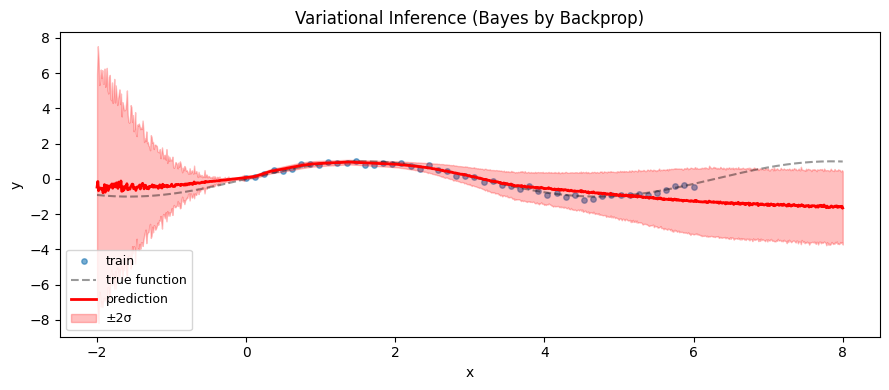

In [7]:
vi_model = train_vi(X_train, y_train, epochs=1000, seed=SEED)
y_pred, y_std = vi_predict(vi_model, X_eval)
show(y_pred, y_std, "Variational Inference (Bayes by Backprop)", f"{FIGDIR}/n50_vi.png")